# Approaching ML problems 

# Phase 1 - Preprocessing and analysis

## 1. Load dataset and see the data using info , head , describe etc 


## 2. Visualise missing values

Matrix

Correlation Heatmap

Dendrogram

Simple numerical summaries

### 2.1 Matrix 

```
        import missingno as msno

        msno.matrix(df)
        plt.figure(figsize = (15,9))
        plt.show()

```

### 2.2 Correlation heatmap

Correlation heatmap measures nullity correlation between columns of the dataset. It shows how strongly the presence or absence of one feature affects the other.

Nullity correlation ranges from(-1 to 1):

-1 means if one column(attribute) is present, the other is almost certainly absent.
0 means there is no dependence between the columns(attributes).
1 means if one column(attributes) is present, the other is also certainly present


    msno.heatmap(df, labels = True)


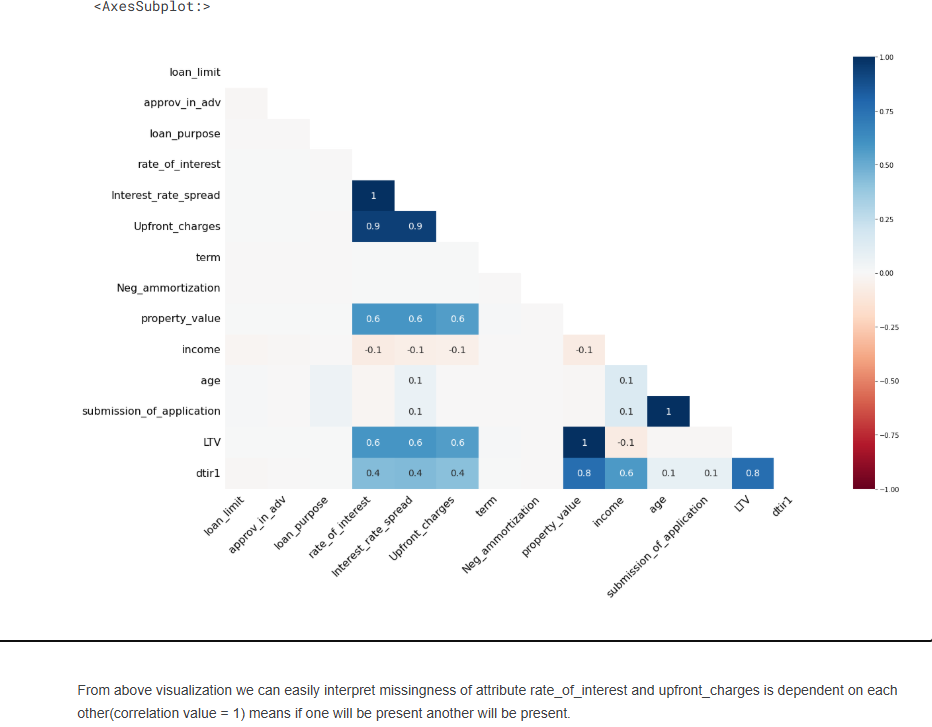

### 2.3 Numerical


        def get_numerical_summary(df):
            total = df.shape[0]
            missing_columns = [col for col in df.columns if df[col].isnull().sum() > 0]
            missing_percent = {}
            for col in missing_columns:
                null_count = df[col].isnull().sum()
                per = (null_count/total) * 100
                missing_percent[col] = per
                print("{} : {} ({}%)".format(col, null_count, round(per, 3)))
            return missing_percent

## 3. EDA on missing data 

Some patterns in missingness might reveal domain knowledge or need specific strategies (e.g., imputing based on grouped medians).

Suggested:
Do basic EDA (Step 4) before deciding how to handle missing values.

## 4. Handling missing values


    Deletion of Data

    Encoding Missingness

    Imputation Methods

### 4.1 Deletion of data

Note: When it is difficult to obtain samples or when the data contain a small number of samples (i.e., rows), then it is not desirable to remove samples from the data.

Consider this small intuition shown below

Let M = Number of Samples(rows).\ and Let N = Number of Attributes(columns).

Case 1: Deletion of Attributes

If N has range of [1-10]\ Then don't delete the attribute that contain missing values but if that attribute has missing values around 80-90% then deletion of that attribute will be good option instead of just predicting values of those 80-90% data based on that 10-20% data.

Case 2: Deletion of Samples

If M is a large number according to your task\ Then deletion of sample can be a Good step but if that sample has few missing values with respect to attribute, then you should consider methods to fill those missing values.

### 4.2 Encoding missingness

#### 4.2.1 Create a new category


When an attribute is discrete in nature, missingness can be directly encoded into the attribute as if it were a naturally occurring category. For example in this dataset the attribute loan_limit has 3344 missing values so we can assign some new category to these missing values.

        df[cat_missing_cols] = df[cat_missing_cols].fillna('Missing')

### 4.3 Imputing data

Another approach to handling missing values is to impute or estimate them. Imputation uses information and relationships among the non-missing attributes to provide an estimate to fill in the missing value.

In this section we will work on imputation models which will help us impute missing values by extracting interesting patterns from attributes which don't have missing values at that point on time.

Within a sample data point, other variables may also be missing. For this reason, an imputation method should be tolerant of other missing data.

Imputation creates a model embedded within another model. There is a prediction equation associated with every attribute in the training set that might have missing data. It is desirable for the imputation method to be fast and have a compact prediction equation.

Many data sets often contain both numeric and discrete attributes. Rather than generating dummy variables for discrete attributes, a useful imputation method would be able to use attributes of various types as inputs.

The model for predicting missing values should be numerically stable and not be overly influenced by outlying data points.

Virtually any machine learning model could be used to impute the data. Here, the focus will be on several that are good candidates to consider.

Question arise if an attribute has missing values around 50-60% then can we use imputation methods? And the answer is it depends upon datasets which we are using because an attribute with 60% missing values may has very good correlation with some other attribute which can be helpful to fill those missing values on the other side if let say some column like ID column which is independent of all columns has missing values around 10% using imputation methods we may not get results we wanted.

In this notebook we are gonna work on following imputation methods:-

KNN for Imputation
Tree Based Imputation
Linear Models for Imputation

#### 4.3.1 KNN For imputation

When the training set is small or moderate in size, K-nearest neighbors can be a quick and effective method for imputing missing values. This procedure identifies a sample with one or more missing values. Then it identifies the K most similar samples in the training data that are complete (i.e., have no missing values in some columns). Similarity of samples for this method is defined by a distance metric. When all of the predictors are numeric, standard Euclidean distance is commonly used as the similarity metric.

After computing the distances, the K closest samples to the sample with the missing value are identified and the average value of the predictor of interest is calculated. This value is then used to replace the missing value of the sample.


        from sklearn.impute import KNNImputer

        df_temp = df.copy()

        knn = KNNImputer(n_neighbors = 3)

        knn.fit(df_temp)

        X = knn.transform(df_temp)

#### 4.3.2 Trees for imputation

Tree-based models are a reasonable choice for an imputation technique since a tree can be constructed in the presence of other missing data. While a single tree could be used as an imputation technique, it is known to produce results that have low bias but high variance. And we all know who kills the bias its Ensembles of trees.

Random forests is one such technique and has been studied for this purpose. However, there are a couple of notable drawbacks when using this technique in a predictive modeling setting. First and foremost, the random selection of predictors at each split necessitates a large number of trees (500 to 2000) to achieve a stable, reliable model. This can present a challenge as the number of attributes with missing data increases since a separate model must be built and retained for each predictor. Also Random forest will have heavy computations.

A good alternative that has a smaller computational footprint is a bagged tree. A bagged tree is constructed in a similar fashion to a random forest. The primary difference is that in a bagged model, all attributes are evaluated at each split in each tree. The performance of a bagged tree using 25–50 trees is generally in the ballpark of the performance of a random forest model. And the smaller number of trees is a clear advantage when the goal is to find reasonable imputed values for missing data.

        from sklearn.tree import DecisionTreeRegressor

        cat_cols = [col for col in df.columns if df[col].dtype == 'object']

        for col in cat_cols:
            df[col] = lb.fit_transform(df[col])
            
        def tree_imputation(df):
            
            missing_cols = [col for col in df.columns if df[col].isnull().sum() > 0]
            non_missing_cols = [col for col in df.columns if df[col].isnull().sum() == 0]
            # num_cols = [col for col in missing_cols if df[col].dtype != 'object']

            # df = df[num_cols]
            for col in missing_cols:

                # Defining a new bagging model for each attribute  
                model = BaggingRegressor(DecisionTreeRegressor(), n_estimators = 40, max_samples = 1.0, max_features = 1.0, bootstrap = False, n_jobs = -1)

                col_missing = df[df[col].isnull()]
                temp = df.drop(df[df[col].isnull()].index, axis = 0)

                # print(temp.columns)
                # X = temp.drop(col, axis = 1)
                X = temp.loc[:, non_missing_cols]
                y = temp[col]

                model.fit(X, y)

                y_pred = model.predict(col_missing[non_missing_cols])
                # col_missing[col] = y_pred

                df.loc[col_missing.index, col] = y_pred
                
            return df

#### 4.3.3 Linear methods

When a complete Attribute shows a strong linear relationship with a attribute that requires imputation, a straightforward linear model may be the best approach. Linear models can be computed very quickly. Linear regression can be used for a numeric attribute that requires imputation. Similarly, logistic regression is appropriate for a categorical attribute that requires imputation.

Let say feature rate_of_interest and Interest_rate_spread are dependent features means one feature can be defined using other. If feature rate_of_interest has missing values than it can be imputed using simple linear model trained on Interest_rate_spread.

## 5. EDA 

✅ EDA Should Be Done Before Encoding (Mostly)
Why?
EDA helps you understand the raw data — its distribution, relationships, and quality — before you alter it.

Encoding transforms categorical variables, which can:

Inflate feature count (especially with One-Hot Encoding).

Hide the original labels, making plots and interpretation harder.

Create misleading graphs (e.g., bar plots on integers that used to be categories).

🔍 How to Approach EDA in Practice:
1. Before Encoding
✅ Check missing values

✅ Understand categorical distributions

✅ Boxplots / barplots between categorical features and numerical targets

✅ Correlation heatmaps (numerical only)

✅ Detect outliers

✅ Check skewness / distribution of numerical features

Example:

python
Copy
Edit
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
This is meaningful only before encoding.

2. After Encoding
✅ Use for model training and feature selection

✅ Correlation matrix on encoded features (e.g., one-hot features)

✅ Feature importance analysis

✅ If using Ordinal Encoding, you can optionally perform EDA to check correlations after encoding (but not for one-hot).

🔁 Exception: EDA After Encoding
You might do additional EDA after encoding if:

You used ordinal encoding and want to verify if the order is meaningful.

You're inspecting feature importances post-training.

You're analyzing feature interaction in high-cardinality categories.

🧠 Final Rule of Thumb:
Do EDA on raw data to gain insights.
Encode only when preparing the data for modeling.

### 5.1 Uni-variant analysis 

Lets look at our data distribution, using univariate analysis (analysis of 1 variable). 

What we might look for in histograms:

Data distribution ( certain models prefer less skewed distributions )

Outliers ( Low Noise Assumption can be detremental to model performance )

Odd patterns in data ( Data abnormalities also affect model performance )

Axis Scale ( Feature scale values can affect a models performance )



### 5.2 Bi-variant analysis 

***Bivariate correlation matrix*** 

Bivariate (Two Feature) Two-Feature relation ; correlation meature

Very fast way to understand something about the dataset.

Correlation matrix contains only information about the linear similarity of two feature relations

***What we might look for:*** 

Often emphasised that too highly or too lowly correlated features should be dropped

Any signs of nonlinearity in the dataset, such as a fair few low linear correlation values

High correlation values between multiple features could indicate that features may represent similar things


***Pairplots/Scatter***  

Matrices are very insightful & can be used to find interesting scatter platterns in bivariate (two feature data plots) relations
Scatter plots allow the addition of color labelling, however its often quite difficult to distinguish between color labels in a scattered matrix

***What we might look for:*** 

Irregular two feature patterns or outliers ( multiple features give a clearer picture of outlier )

Two dimensional Data clusters (using KDE approximation)

Two feature linear correlation value visualisation in two dimensional space ( is the data sorted linearly or completly random )

### 5.3 Multi-variant analysis

Multivariate visualisating can be even more insightful than bivariate. Adding 'hue'/colour to scattered data gives the data an extra dimension we can interpred provided there is minimal overlap

Geographic plotting is one form of such visualisation. It would be interesting to understand how geography influences various features.

We're dealing with geographical data, so geopandas is quite useful, so is folium & plotly

Other modules you might like to add (mainly for 3D) k3d and pyvista are awesome for multivariate visualisation too.

## 6. Dealing with outliers

After doing uni-variant and bi-variant analysis we should be able to figure out the outliers 



        maxval2 = trdata['median_house_value'].max() # get the maximum value
        trdata_upd = trdata[trdata['median_house_value'] != maxval2] 
        tedata_upd = tedata[tedata['median_house_value'] != maxval2]
        trdata_upd.hist(bins=60, figsize=(15,9),color=color1);plt.show()

## 7. Encoding 

Categorical Features are those that contain qualitative data.This Section focuses primarily on methods that encode categorical data to numeric values.

Categorical variables/features are any feature type can be classified into three major types:

Nominal
Ordinal
Binary
Nominal variables are variables that have two or more categories which do not have any kind of order associated with them. For Example if our dataset has any 4 types of colors, i.e. Red, Blue, Orange, Green it can be considered as a nominal variable.

Ordinal variables on the other hand, have “levels” or categories with a particular order associated with them. For example, an ordinal categorical variable can be a feature with three different levels: low, medium and high. Order is important.

Binary Variables are same as nominal variables but with only categories For example, if gender is classified into two groups, i.e. male and female.

One-Hot-Encoding has the advantage that the result is binary rather than ordinal and that everything sits in an orthogonal vector space. The disadvantage is that for high cardinality, the feature space can really blow up quickly and you start fighting with the curse of dimensionality.

## 8. EDA on encoded data

 Optional step, only useful when:

You want to do feature selection post-encoding.

You encoded ordinal features and want to verify correlation.

You want to explore feature importance from models.



## 9. Feature selection

1. Remove Low-Variance Features
Features that have the same value across most samples do not help the model.

python
Copy
Edit
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
reduced_X = selector.fit_transform(X)

2. Remove Highly Correlated Features (Multicollinearity)
Use Pearson correlation matrix for numerical features.

python
Copy
Edit
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
df.drop(columns=to_drop, inplace=True)

3. Univariate Feature Selection
Use statistical tests to score each feature individually.

python
Copy
Edit
from sklearn.feature_selection import SelectKBest, f_classif, f_regression



4. Recursive Feature Elimination (RFE)
Recursively removes least important features using model coefficients or feature importance.

python
Copy
Edit
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)


5. Feature Importance from Models
Tree-based models and linear models provide feature importance or coefficients.

python
Copy
Edit
model = RandomForestRegressor()
model.fit(X, y)
importances = model.feature_importances_


6. Lasso Regularization (L1)
Automatically sets irrelevant feature coefficients to zero.

python
Copy
Edit
from sklearn.linear_model import LassoCV
model = LassoCV()
model.fit(X, y)
selected_features = X.columns[(model.coef_ != 0)]


✨ Tips:
Use domain knowledge to keep meaningful features even if statistical tests suggest otherwise.

Always validate model performance (via cross-validation) after feature selection.

## 10. Data splitting

Points to consider while doing train_test_split

So far we have considered purely random sampling methods. This is generally fine if your dataset is large enough (especially relative to the number of attributes), but if it is not, you run the risk of introducing a significant sampling bias.

When a survey company decides to call 1,000 people to ask them a few questions, they don’t just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people are representative of the whole population.

For example, the US population is composed of 51.3% female and 48.7% male, so a well-conducted survey in the US would try to maintain this ratio in the sample: 513 female and 487 male. This is called stratified sampling: the population is divided into homogeneous subgroups called strata, and the right number of instances is sampled from each stratum to guarantee that the test set is representative of the overall population.

***Business insights***

Suppose you chatted with experts who told you that the median income is a very important attribute to predict median housing prices.

You may want to ensure that the test set is representative of the various categories of incomes in the whole dataset.

Since the median income is a continuous numerical attribute, you first need to create an income category attribute.

Let’s look at the median income histogram more closely (back in Figure of histograms): most median income values are clustered around 1.5 to 6 (i.e., 15, 000–60,000), but some median incomes go far beyond 6.

It is important to have a sufficient number of instances in your dataset for each stratum, or else the estimate of the stratum’s importance may be biased. This means that you should not have too many strata, and each stratum should be large enough.

The following code uses the pd.cut() function to create an income category attribute with 5 categories (labeled from 1 to 5): category 1 ranges from 0 to 1.5 (i.e., less than $15,000), category 2 from 1.5 to 3, and so on



        df["income_cat"] = pd.cut(df["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

        from sklearn.model_selection import StratifiedShuffleSplit

        split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)  # Provides train/test indices to split data in train/test sets.
        for train_index, test_index in split.split(df, df["income_cat"]):
            strat_train_set = df.loc[train_index]
            strat_test_set = df.loc[test_index]

If you're scaling:
Do NOT scale the entire dataset first.

Instead:

Split the data first, then

Fit the scaler (e.g., StandardScaler) only on the training data

Transform both train and test sets using this fitted scaler




        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler

        # Split first
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Then scale
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

## 11. Feature scaling

### 1. Standardization (Z-score scaling)
Mean = 0, Std Dev = 1

python
Copy
Edit
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2. Min-Max Normalization
Scales values between 0 and 1

python
Copy
Edit
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

### 3. Robust Scaling
Uses median and IQR — useful for data with outliers

python
Copy
Edit
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
### 4. MaxAbsScaler
Scales by maximum absolute value (used for sparse data)

python
Copy
Edit
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X)

## 12. EDA on scaled data 

# Guide for choosing Model and their use cases

## Model Selection Guide



### Supervised regression


#### Factors 


| Factor                          | Why It Matters                                         | Example Insight                                     |
| ------------------------------- | ------------------------------------------------------ | --------------------------------------------------- |
| **Data Size**                   | Simple models perform well on small data               | Linear models for <10K rows                         |
| **Linearity of Data**           | Detect linear vs nonlinear patterns                    | Use regression plots or residuals                   |
| **Outliers**                    | Some models are sensitive to them                      | Linear regression is sensitive; tree models are not |
| **Feature-Target Relationship** | Linear or complex interaction                          | Use scatter plots, correlation                      |
| **Multicollinearity**           | High correlation among features affects linear models  | Check with VIF or heatmaps                          |
| **Need for Interpretability**   | Linear models are explainable; ensemble models are not | Use when model explanation is key                   |

#### Guide

| Model                                     | When to Use                                                                     | Pros                                  | Cons                                     |
| ----------------------------------------- | ------------------------------------------------------------------------------- | ------------------------------------- | ---------------------------------------- |
| **Linear Regression**                     | - Target varies linearly with features<br>- Few features, low multicollinearity | Fast, interpretable                   | Sensitive to outliers, assumes linearity |
| **Ridge/Lasso Regression**                | - Multicollinearity present<br>- Feature selection needed                       | Lasso helps in feature selection      | Still assumes linearity                  |
| **Polynomial Regression**                 | - Known non-linear relationship                                                 | Models curves                         | Can overfit, needs tuning                |
| **KNN Regressor**                         | - Non-parametric, works on smaller data                                         | Simple, no training needed            | Slow on large data, sensitive to scale   |
| **Decision Tree Regressor**               | - Non-linear data<br>- Interpretability needed                                  | Handles missing data, no scaling      | Can overfit without pruning              |
| **Random Forest Regressor**               | - Strong baseline model<br>- Medium to large datasets                           | Robust, handles non-linearity         | Less interpretable                       |
| **Gradient Boosting (XGBoost, LightGBM)** | - Complex datasets, high accuracy needed                                        | Best performance in many cases        | Needs tuning, less interpretable         |
| **SVR (Support Vector Regression)**       | - Smaller datasets<br>- Outlier-robust                                          | Works well on small, complex problems | Slower, sensitive to feature scaling     |

### Supervised Classification

#### Factors

| Factor                          | Why It Matters                                     | Example Insight                            |
| ------------------------------- | -------------------------------------------------- | ------------------------------------------ |
| **Class Balance**               | Some models struggle with imbalanced classes       | Check value counts, use SMOTE              |
| **Feature-Target Relationship** | Linearly separable or not                          | Use scatter plots or PCA                   |
| **Data Size**                   | Simpler models perform well on smaller data        | Naive Bayes, Logistic for <10K rows        |
| **Speed vs Accuracy**           | Tree models give good trade-off                    | Ensemble models = slower but more accurate |
| **Interpretability**            | Business use-cases may demand interpretable models | Use Logistic Regression, Trees             |
| **Multiclass vs Binary**        | Some models are inherently binary                  | Logistic needs One-vs-Rest for multiclass  |

#### Guide

| Model                                     | When to Use                                         | Pros                          | Cons                                   |
| ----------------------------------------- | --------------------------------------------------- | ----------------------------- | -------------------------------------- |
| **Logistic Regression**                   | - Binary classification<br>- Linear separation      | Fast, interpretable           | Not good for non-linear data           |
| **KNN Classifier**                        | - Small datasets, simple structure                  | Intuitive, no training        | Sensitive to scale, slow at prediction |
| **Naive Bayes**                           | - Text data, independence assumption holds          | Fast, good baseline           | Assumes feature independence           |
| **Decision Tree Classifier**              | - Interpretability needed<br>- Non-linear patterns  | Easy to explain               | Prone to overfitting                   |
| **Random Forest Classifier**              | - Robust and reliable<br>- Medium to large datasets | Great accuracy, handles noise | Slower, less interpretable             |
| **Gradient Boosting (XGBoost, LightGBM)** | - Tabular data, competition-level accuracy          | Top performance               | Hyperparameter tuning required         |
| **SVM (Support Vector Machine)**          | - Smaller datasets<br>- High-dimensional space      | Works well with margins       | Slow, hard to scale                    |
| **Neural Networks (MLPClassifier)**       | - Larger datasets<br>- Complex patterns             | Captures complex interactions | Needs tuning, less interpretable       |


# Phase 2 - Modelling

## 13. Model selection

Try multiple algorithms and pick the best-performing ones for tuning.


        from sklearn.pipeline import Pipeline
        from sklearn.ensemble import RandomForestClassifier

        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(random_state=42))
        ])
        pipeline.fit(X_train, y_train)

## 14. Estimate model performance more reliably by using K-Fold cross-validation.

        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

## 15. Optimize model parameters to improve performance.


        from sklearn.model_selection import GridSearchCV

        param_grid = {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20]
        }

        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

## 16. Model evaluation

Goal: Evaluate final model on test data using appropriate metrics.


Classification: accuracy_score, precision, recall, f1_score, confusion_matrix, ROC AUC

Regression: mean_squared_error, r2_score, MAE

            from sklearn.metrics import accuracy_score
            y_pred = best_model.predict(X_test)
            accuracy_score(y_test, y_pred)